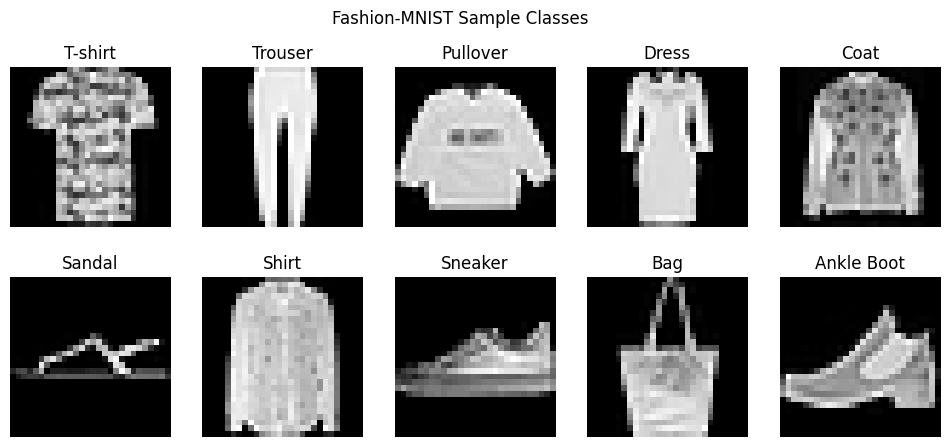


Original Dimension : 784
Reduced Dimension  : 50


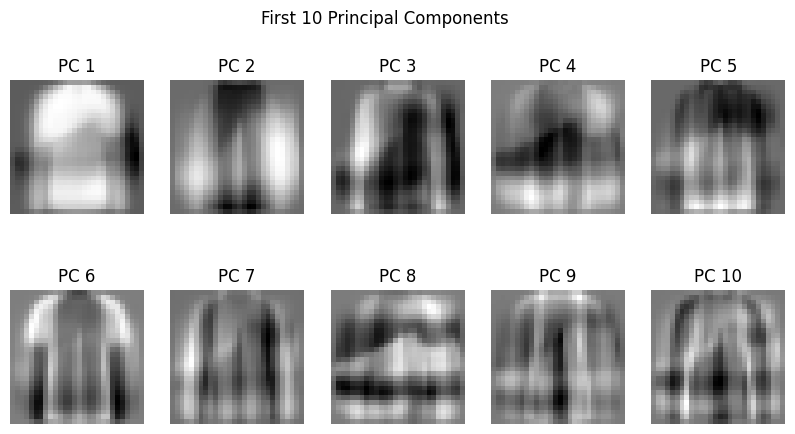

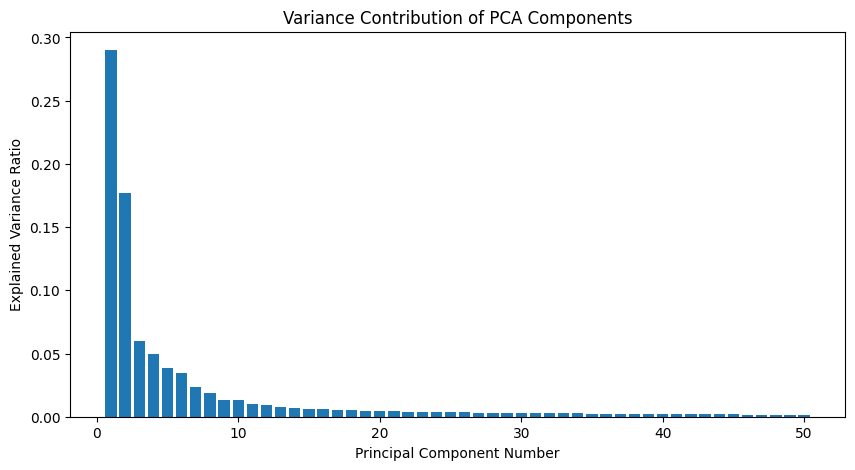

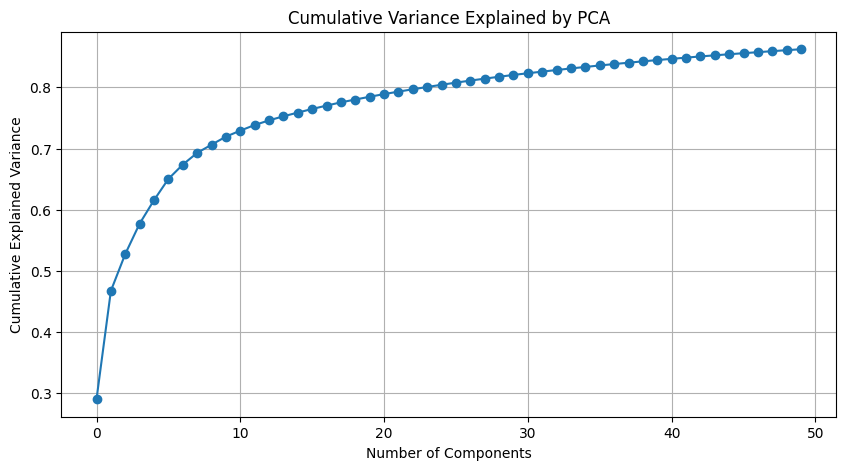

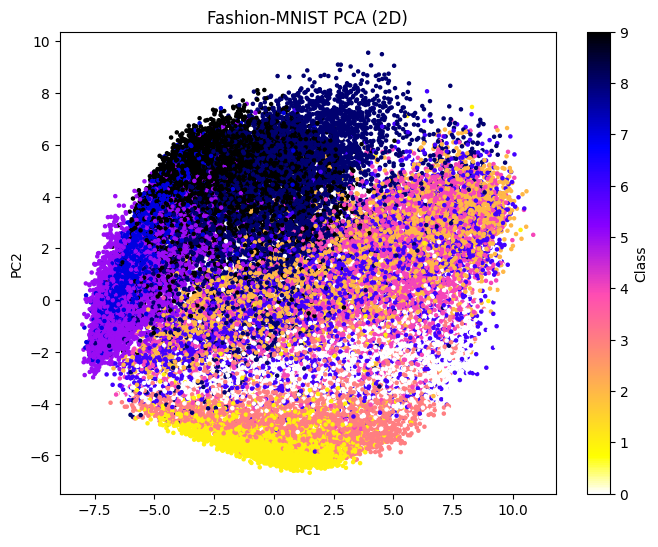

>epoch=0, error=201577.888, train_acc=12.04%
>epoch=1, error=48276.693, train_acc=29.85%
>epoch=2, error=38693.037, train_acc=49.77%
>epoch=3, error=31486.928, train_acc=61.51%
>epoch=4, error=25632.866, train_acc=68.99%
>epoch=5, error=22693.887, train_acc=72.19%
>epoch=6, error=20789.166, train_acc=75.51%
>epoch=7, error=19057.915, train_acc=78.20%
>epoch=8, error=17836.617, train_acc=79.90%
>epoch=9, error=17020.078, train_acc=80.89%
>epoch=10, error=16418.987, train_acc=81.55%
>epoch=11, error=15957.312, train_acc=82.03%
>epoch=12, error=15587.516, train_acc=82.45%
>epoch=13, error=15280.439, train_acc=82.82%
>epoch=14, error=15019.888, train_acc=83.10%
>epoch=15, error=14794.774, train_acc=83.33%
>epoch=16, error=14598.727, train_acc=83.48%
>epoch=17, error=14426.844, train_acc=83.66%
>epoch=18, error=14275.838, train_acc=83.83%
>epoch=19, error=14143.009, train_acc=83.98%
>epoch=20, error=14025.361, train_acc=84.16%
>epoch=21, error=13920.018, train_acc=84.32%
>epoch=22, error=13

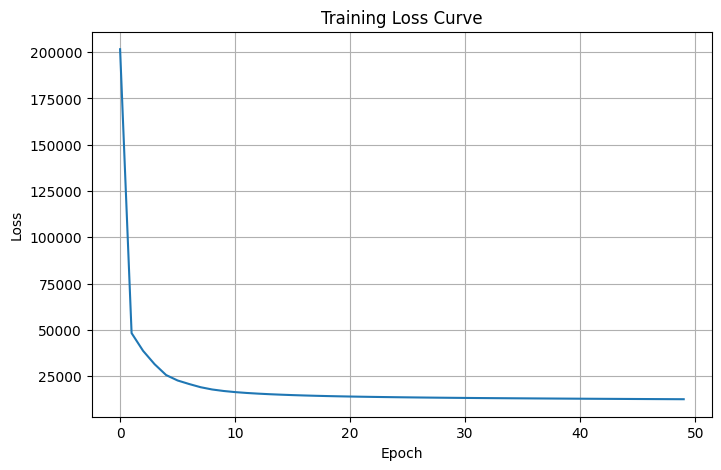

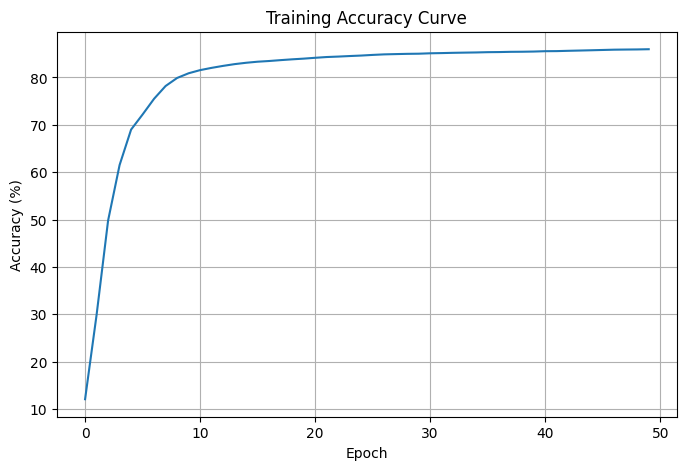


Test Accuracy = 85.13%


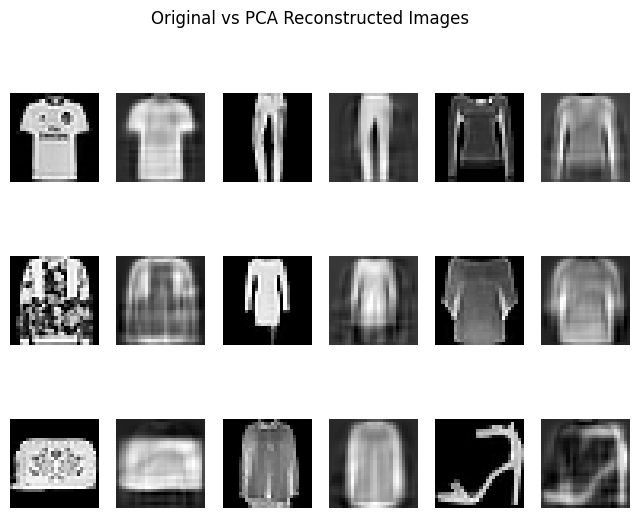

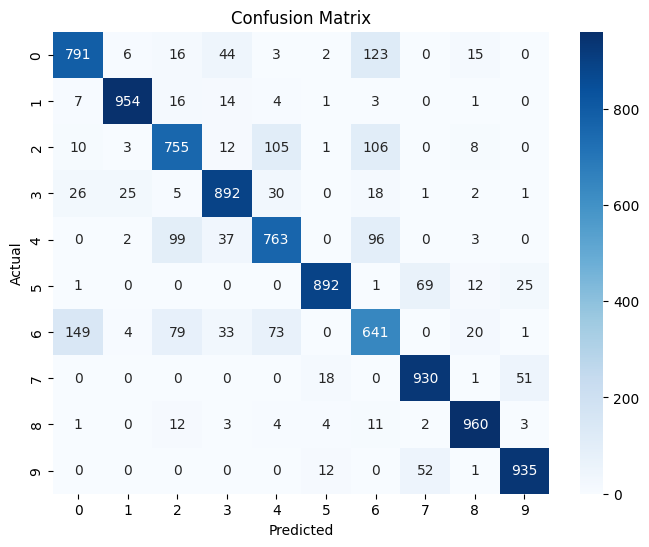


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1000
           1       0.96      0.95      0.96      1000
           2       0.77      0.76      0.76      1000
           3       0.86      0.89      0.88      1000
           4       0.78      0.76      0.77      1000
           5       0.96      0.89      0.92      1000
           6       0.64      0.64      0.64      1000
           7       0.88      0.93      0.91      1000
           8       0.94      0.96      0.95      1000
           9       0.92      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



<Figure size 1200x500 with 0 Axes>

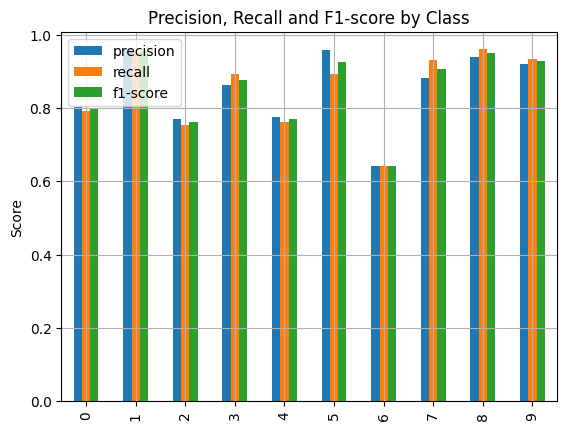

In [ ]:
from random import random, seed
from math import exp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# =====================================================
# Neural Network Functions
# =====================================================

def initialize_network(n_inputs, n_h1, n_h2, n_outputs):
    network = list()

    hidden_layer1 = [
        {'weights': [random() for i in range(n_inputs + 1)]}
        for i in range(n_h1)
    ]
    network.append(hidden_layer1)

    hidden_layer2 = [
        {'weights': [random() for i in range(n_h1 + 1)]}
        for i in range(n_h2)
    ]
    network.append(hidden_layer2)

    output_layer = [
        {'weights': [random() for i in range(n_h2 + 1)]}
        for i in range(n_outputs)
    ]
    network.append(output_layer)

    return network


def activate(weights, inputs):
    activation = weights[-1]

    for i in range(len(weights) - 1):
        activation += weights[i] * inputs[i]

    return activation


def transfer(activation):
    return 1.0 / (1.0 + exp(-activation))


def forward_propagate(network, row):
    inputs = row

    for layer in network:
        new_inputs = []

        for neuron in layer:
            activation = activate(neuron['weights'], inputs)
            neuron['output'] = transfer(activation)
            new_inputs.append(neuron['output'])

        inputs = new_inputs

    return inputs


def transfer_derivative(output):
    return output * (1.0 - output)


def backward_propagate_error(network, expected):

    for i in reversed(range(len(network))):

        layer = network[i]
        errors = []

        if i != len(network) - 1:

            for j in range(len(layer)):
                error = 0.0

                for neuron in network[i + 1]:
                    error += neuron['weights'][j] * neuron['delta']

                errors.append(error)

        else:

            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(neuron['output'] - expected[j])

        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = (
                errors[j] *
                transfer_derivative(neuron['output'])
            )


def update_weights(network, row, l_rate):

    for i in range(len(network)):

        inputs = row[:-1]

        if i != 0:
            inputs = [
                neuron['output']
                for neuron in network[i - 1]
            ]

        for neuron in network[i]:

            for j in range(len(inputs)):
                neuron['weights'][j] -= (
                    l_rate *
                    neuron['delta'] *
                    inputs[j]
                )

            neuron['weights'][-1] -= (
                l_rate *
                neuron['delta']
            )

def train_network(network, train, l_rate, n_epoch, n_outputs):

    loss_history = []
    accuracy_history = []

    for epoch in range(n_epoch):

        sum_error = 0
        correct = 0

        for row in train:

            outputs = forward_propagate(
                network,
                row[:-1]
            )

            expected = [0 for _ in range(n_outputs)]
            expected[row[-1]] = 1

            sum_error += sum(
                (expected[i] - outputs[i])**2
                for i in range(n_outputs)
            )

            prediction = outputs.index(max(outputs))

            if prediction == row[-1]:
                correct += 1

            backward_propagate_error(
                network,
                expected
            )

            update_weights(
                network,
                row,
                l_rate
            )

        train_acc = (
            correct /
            len(train)
        ) * 100

        loss_history.append(sum_error)
        accuracy_history.append(train_acc)

        print(
            '>epoch=%d, error=%.3f, train_acc=%.2f%%'
            %
            (
                epoch,
                sum_error,
                train_acc
            )
        )

    return loss_history, accuracy_history

def predict(network, row):
    outputs = forward_propagate(network, row)
    return outputs.index(max(outputs))


# =====================================================
# Load Fashion-MNIST Datasets
# =====================================================

seed(1)

train_df = pd.read_csv('/content/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/fashion-mnist_test.csv')

train_df.dropna(inplace=True)
train_df.reset_index(drop=True, inplace=True)

X_train_original = train_df.iloc[:, 1:].values
X_test_original = test_df.iloc[:, 1:].values


y_train = train_df.iloc[:, 0].values
y_test = test_df.iloc[:, 0].values

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):

    idx = np.where(y_train == i)[0][0]

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_train_original[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(class_names[i])

    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Classes")
plt.show()

# =====================================================
# Normalization
# =====================================================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train_original)
X_test = scaler.transform(X_test_original)

# =====================================================
# PCA
# =====================================================

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("\nOriginal Dimension :", X_train.shape[1])
print("Reduced Dimension  :", X_train_pca.shape[1])

#PCA Components Visualisation
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        pca.components_[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(f"PC {i+1}")

    plt.axis('off')

plt.suptitle("First 10 Principal Components")
plt.show()

#Explained Variance Plot
explained_variance = pca.explained_variance_ratio_

components = np.arange(
    1,
    len(explained_variance)+1
)

plt.figure(figsize=(10,5))

plt.bar(
    components,
    explained_variance
)

plt.xlabel("Principal Component Number")
plt.ylabel("Explained Variance Ratio")

plt.title(
    "Variance Contribution of PCA Components"
)

plt.show()

#Cummulative Variancce Plot
plt.figure(figsize=(10,5))

plt.plot(
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "Cumulative Variance Explained by PCA"
)

plt.grid(True)

plt.show()

#2D PCA Visualisation
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=y_train,
    cmap='gnuplot2_r',
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Fashion-MNIST PCA (2D)")

plt.colorbar(
    scatter,
    label='Class'
)

plt.show()

# =====================================================
# Create Training Dataset
# =====================================================

train_dataset = [
    list(X_train_pca[i]) + [y_train[i]]
    for i in range(len(y_train))
]

n_inputs = len(train_dataset[0]) - 1
n_outputs = len(set(y_train))

# =====================================================
# Initialize Network
# =====================================================

network = initialize_network(
    n_inputs,
    15,
    16,
    n_outputs
)

# =====================================================
# Train Network
# =====================================================

loss_history, accuracy_history = train_network(
    network,
    train_dataset,
    l_rate=0.01,
    n_epoch=50,
    n_outputs=n_outputs
)

#Training Loss Curve
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

#Training Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(accuracy_history)

plt.title("Training Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()


# =====================================================
# Test Accuracy
# =====================================================

correct = 0

for i in range(len(X_test_pca)):

    prediction = predict(
        network,
        list(X_test_pca[i])
    )

    actual = y_test[i]

    if prediction == actual:
        correct += 1

accuracy = correct / len(X_test_pca) * 100

print("\n================================")
print("Test Accuracy = %.2f%%" % accuracy)
print("================================")

# =====================================================
# PCA Reconstruction Visualization
# =====================================================

reconstructed_images = pca.inverse_transform(
    X_test_pca[:9]
)

plt.figure(figsize=(8, 6))

for i in range(9):

    # Original image
    plt.subplot(3, 6, 2 * i + 1)
    plt.imshow(
        X_test_original[i].reshape(28, 28),
        cmap='gray'
    )
    plt.axis('off')

    # PCA reconstructed image
    plt.subplot(3, 6, 2 * i + 2)
    plt.imshow(
        reconstructed_images[i].reshape(28, 28),
        cmap='gray'
    )
    plt.axis('off')

plt.suptitle(
    "Original vs PCA Reconstructed Images"
)
plt.show()

# Confusion Matrix
y_pred = [
    predict(network, list(X_test_pca[i]))
    for i in range(len(X_test_pca))
]

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =====================================================
# Classification Report
# =====================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

metrics_df = pd.DataFrame(
    report
).transpose()

metrics_df = metrics_df.iloc[:10]

plt.figure(figsize=(12,5))

metrics_df[
    ['precision','recall','f1-score']
].plot(
    kind='bar'
)

plt.title(
    'Precision, Recall and F1-score by Class'
)

plt.ylabel(
    'Score'
)

plt.grid(True)

plt.show()